In [2]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

# Show first 5 rows
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [3]:
df.shape

(9712, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [5]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [6]:
df.isnull().sum()


Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [7]:
df.dropna

<bound method DataFrame.dropna of       Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0      14    Male                      3.99     Smartphone   
1      11  Female                      4.61         Laptop   
2      18  Female                      3.73             TV   
3      15  Female                      1.21         Laptop   
4      12  Female                      5.89     Smartphone   
...   ...     ...                       ...            ...   
9707   17    Male                      3.26     Smartphone   
9708   17  Female                      4.43     Smartphone   
9709   16    Male                      5.62     Smartphone   
9710   17    Male                      5.60             TV   
9711   15  Female                      6.12             TV   

      Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                           True                               0.42   
1                           True                               0.30   
2       

data cleaning

handling missing values

In [8]:
df.dropna()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban
5,14,Female,4.88,Smartphone,True,0.44,Poor Sleep,Urban
...,...,...,...,...,...,...,...,...
9707,17,Male,3.26,Smartphone,True,0.44,Poor Sleep,Urban
9708,17,Female,4.43,Smartphone,True,0.40,Poor Sleep,Rural
9709,16,Male,5.62,Smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural
9710,17,Male,5.60,TV,True,0.43,Poor Sleep,Urban


In [9]:
# Code Cell
df.dropna()

df['Age'].fillna(df['Age'].mean())

0       14
1       11
2       18
3       15
4       12
        ..
9707    17
9708    17
9709    16
9710    17
9711    15
Name: Age, Length: 9712, dtype: int64

standardizing categorical data

In [10]:
df['Gender'] = df['Gender'].str.strip().str.lower()
df['Gender'] = df['Gender'].replace({'m':'male', 'f':'female'})

df['Primary_Device'] = df['Primary_Device'].str.strip().str.lower()
df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban
3,15,female,1.21,laptop,False,0.39,NaN,Urban
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


removing invalid and  duplicate rows

In [11]:
df = df[df['Age'] > 0]
df = df[df['Avg_Daily_Screen_Time_hr'] <= 24]

df.drop_duplicates(inplace=True)
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban
3,15,female,1.21,laptop,False,0.39,NaN,Urban
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban



Create Age Bands(3-5,6-9,10-13,14-17)

In [12]:
# Create Age Bands
bins = [3, 5, 9, 13, 17]
labels = ['3-5', '6-9', '10-13', '14-17']

df['Age_Band'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban,10-13
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban,NaN
3,15,female,1.21,laptop,False,0.39,NaN,Urban,14-17
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13


weekday vs weekend flag

In [13]:
import pandas as pd

bins_Age = [3, 5, 9, 13, 17]
labels_Age = ['3-5', '6-9', '10-13', '14-17']

df['Age_Band'] = pd.cut(df['Age'],
                        bins=bins_Age,
                        labels=labels_Age,
                        include_lowest=True,)
print(df.head())                        

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    male                      3.99     smartphone   
1   11  female                      4.61         laptop   
2   18  female                      3.73             tv   
3   15  female                      1.21         laptop   
4   12  female                      5.89     smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural Age_Band  
0  Poor Sleep, Eye Strain          Urban    14-17  
1              Poor Sleep          Urban    10-13  
2              Poor Sleep          Urban      NaN  
3                     NaN   

In [14]:
df.tail()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
9707,17,male,3.26,smartphone,True,0.44,Poor Sleep,Urban,14-17
9708,17,female,4.43,smartphone,True,0.40,Poor Sleep,Rural,14-17
9709,16,male,5.62,smartphone,True,0.39,"Poor Sleep, Eye Strain, Anxiety",Rural,14-17
9710,17,male,5.60,tv,True,0.43,Poor Sleep,Urban,14-17
9711,15,female,6.12,tv,True,0.33,Anxiety,Urban,14-17


screen time bukets(low/mdium/high)

In [15]:
bins = [0, 2, 5, 24]
labels = ['Low', 'Medium', 'High']

df['ScreenTime_Bucket'] = pd.cut(
    df['Avg_Daily_Screen_Time_hr'],
    bins=bins,
    labels=labels
)

print(df.head())

   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    male                      3.99     smartphone   
1   11  female                      4.61         laptop   
2   18  female                      3.73             tv   
3   15  female                      1.21         laptop   
4   12  female                      5.89     smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural Age_Band ScreenTime_Bucket  
0  Poor Sleep, Eye Strain          Urban    14-17            Medium  
1              Poor Sleep          Urban    10-13            Medium  
2              Poor Sleep 

Delivarable 1: data frame with colums 

In [16]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,ScreenTime_Bucket
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17,Medium
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban,10-13,Medium
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban,NaN,Medium
3,15,female,1.21,laptop,False,0.39,NaN,Urban,14-17,Low
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13,High


Delivarable 2: explanation of new colums

Age_band

What it does:

Groups children into meaningful age categories.

In [17]:
bins_Age = [3, 5, 9, 13, 17, 20]
labels_Age = ['3-5', '6-9', '10-13', '14-17', '18-20']

df['Age_Band'] = pd.cut(df['Age'], bins=bins_Age, labels=labels_Age, include_lowest=True)

df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,ScreenTime_Bucket
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17,Medium
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban,10-13,Medium
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban,18-20,Medium
3,15,female,1.21,laptop,False,0.39,NaN,Urban,14-17,Low
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13,High


In [18]:
df['Age_Band'] = pd.cut(
    df["Age"],
    bins=[0,5,9,13,17],
    labels=["0-5","6-9","10-13","14-17"]
)
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,ScreenTime_Bucket
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17,Medium
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban,10-13,Medium
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban,NaN,Medium
3,15,female,1.21,laptop,False,0.39,NaN,Urban,14-17,Low
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13,High


In [19]:
df["Screen_time_level"] = pd.cut(
    df["Avg_Daily_Screen_Time_hr"],
    bins=[0, 2, 6, 12, 24],
    labels=["low", "moderate", "high", "very high"]
)
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band,ScreenTime_Bucket,Screen_time_level
0,14,male,3.99,smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17,Medium,moderate
1,11,female,4.61,laptop,True,0.30,Poor Sleep,Urban,10-13,Medium,moderate
2,18,female,3.73,tv,True,0.32,Poor Sleep,Urban,NaN,Medium,moderate
3,15,female,1.21,laptop,False,0.39,NaN,Urban,14-17,Low,low
4,12,female,5.89,smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13,High,moderate


In [20]:
import os 
os.getcwd()

'C:\\Users\\Admin\\Downloads\\archive (1)'

In [21]:
import os
os.listdir()

['.ipynb_checkpoints',
 'data',
 'Indian_Kids_Screen_Time.csv',
 'internship.ipynb',
 'notebook2.ipynb']

In [22]:
import pandas as pd

df = pd.read_csv("Indian_Kids_Screen_Time.csv")
df.head()


,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


basic visuvalization


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


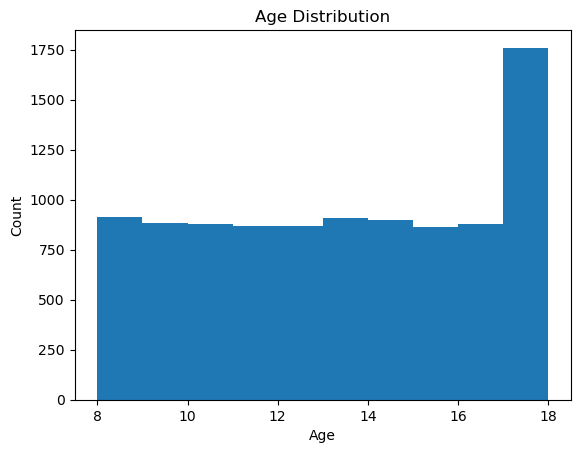

In [24]:


plt.figure()
plt.hist(df['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

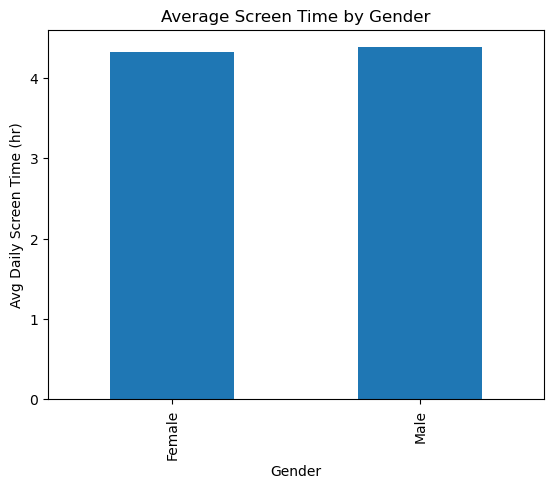

In [25]:
avg_screen_gender = df.groupby('Gender')['Avg_Daily_Screen_Time_hr'].mean()

plt.figure()
avg_screen_gender.plot(kind='bar')
plt.title("Average Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Avg Daily Screen Time (hr)")
plt.show()

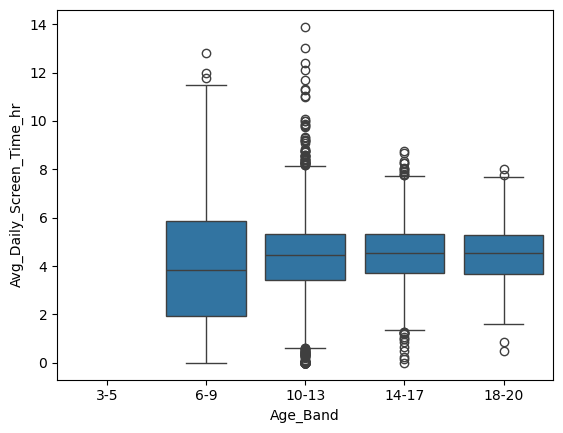

In [26]:

df["Age_Band"] = pd.cut(df["Age"],
                        bins=[3,5,9,13,17,20],
                        labels=["3-5","6-9","10-13","14-17","18-20"])

sns.boxplot(x="Age_Band", y="Avg_Daily_Screen_Time_hr", data=df)
plt.show()

In [27]:
import os
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/scrensense_clean.csv", index=False)
print("Saved!")

Saved!


In [28]:
import pandas as pd

# Read the cleaned CSV
df_check = pd.read_csv("data/processed/scrensense_clean.csv")

# Show first 5 rows
df_check.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural,Age_Band
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban,14-17
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban,10-13
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban,18-20
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban,14-17
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban,10-13


Distribution of avg daily screen time 

goal: see speed,skewness,and outliers
chart type: histogram 

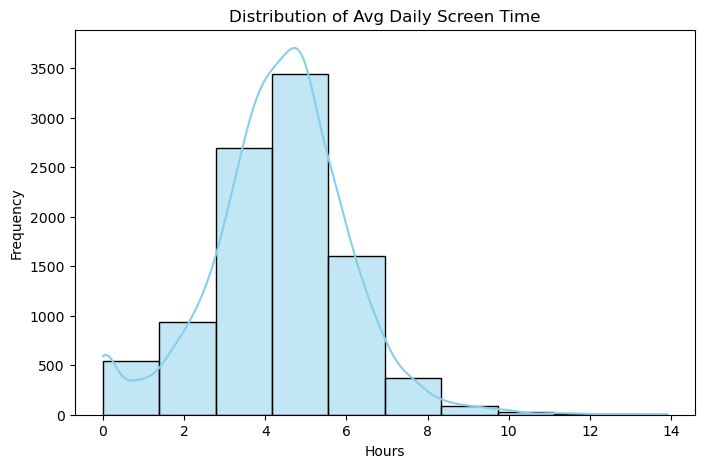

In [29]:

# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Avg Daily Screen Time")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

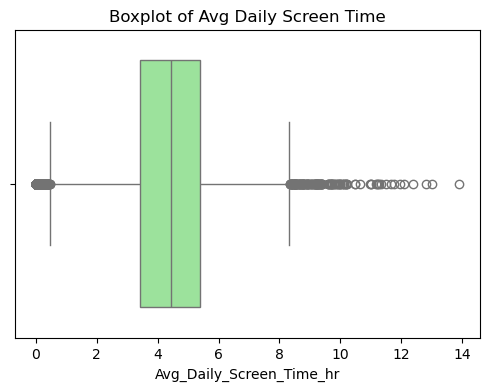

In [30]:

# Boxplot to see outliers
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Avg_Daily_Screen_Time_hr'], color='lightgreen')
plt.title("Boxplot of Avg Daily Screen Time")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\1422405561.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age_Band', data=df, palette='Set2', order=df['Age_Band'].value_counts().index)


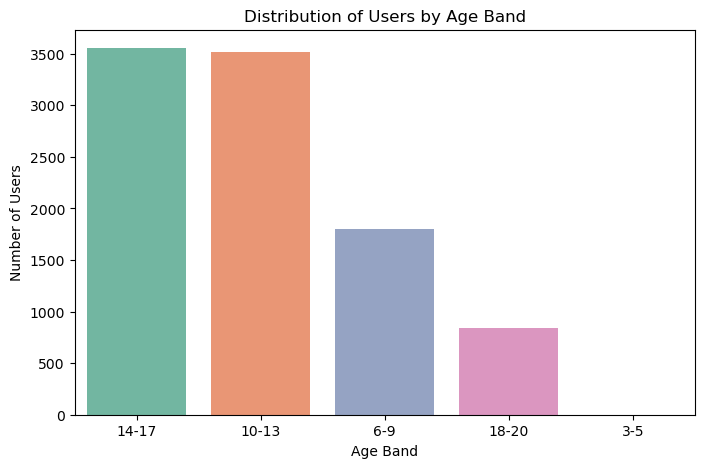

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='Age_Band', data=df, palette='Set2', order=df['Age_Band'].value_counts().index)
plt.title("Distribution of Users by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Number of Users")
plt.show()

interpretation:
the tallest bar : age band with the most users(dominates tge dataset)

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\535160693.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Primary_Device', data=df, palette='Set3', order=df['Primary_Device'].value_counts().index)


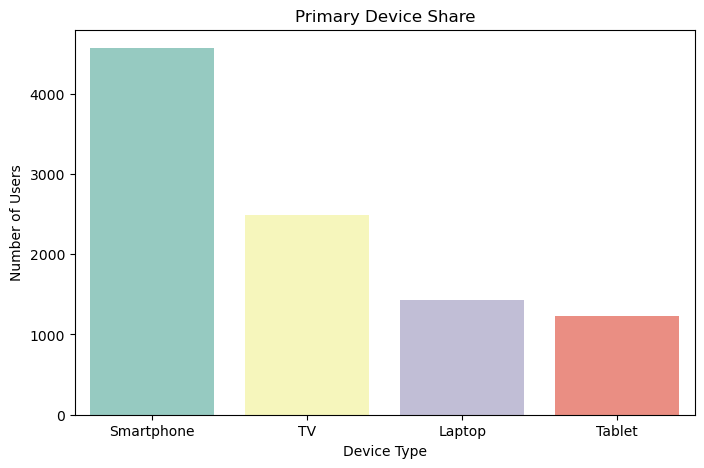

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', data=df, palette='Set3', order=df['Primary_Device'].value_counts().index)
plt.title("Primary Device Share")
plt.xlabel("Device Type")
plt.ylabel("Number of Users")
plt.show()

interpretation:
the device with the highest bar mostly commonly used device


Avg Daily Screen Time

Screen Time by Age Bnad

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\1736920194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set2', order=df['Age_Band'].value_counts().index)


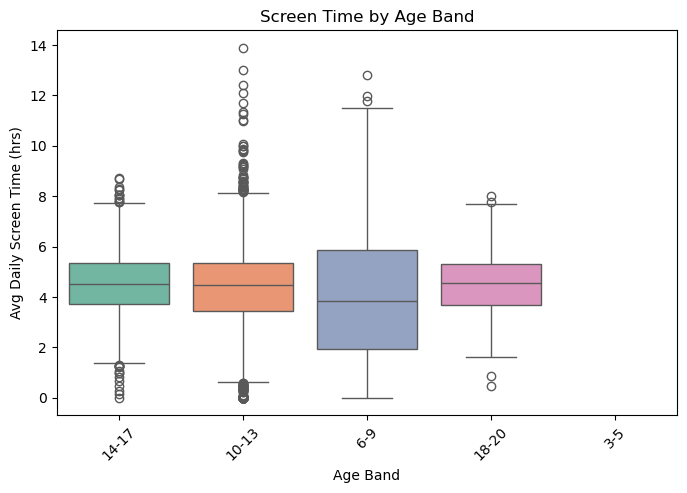

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Age_Band', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set2', order=df['Age_Band'].value_counts().index)
plt.title("Screen Time by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Avg Daily Screen Time (hrs)")
plt.xticks(rotation=45)
plt.show()

helps identify which age goup use screen the most and outliers

screen time by location type

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\4072279467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set3')


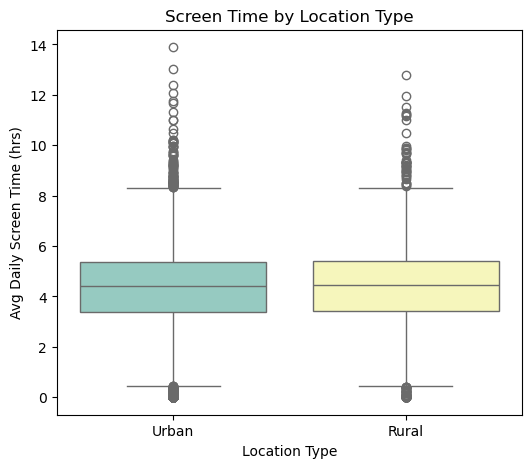

In [34]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set3')
plt.title("Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Avg Daily Screen Time (hrs)")
plt.show()

compare screen time betwen urben vs rural users

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\3637995716.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_band_mean = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean().reset_index()
C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\3637995716.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_band_mean, x="Age_Band", y="Avg_Daily_Screen_Time_hr", palette='Set2')


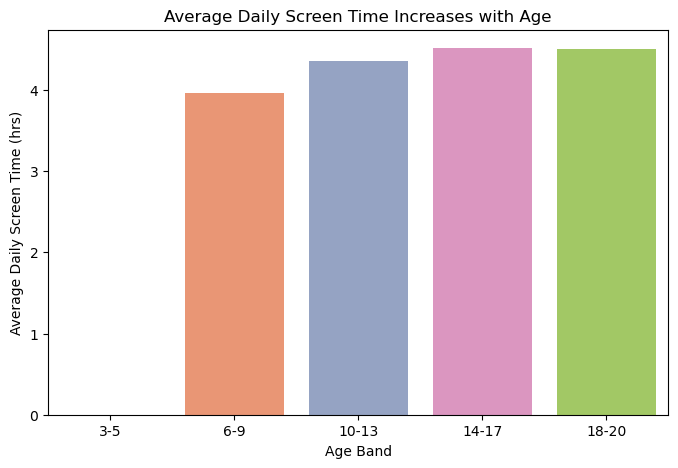

In [35]:
# Grouping
age_band_mean = df.groupby("Age_Band")["Avg_Daily_Screen_Time_hr"].mean().reset_index()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=age_band_mean, x="Age_Band", y="Avg_Daily_Screen_Time_hr", palette='Set2')
plt.title("Average Daily Screen Time Increases with Age")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.show()

Gender vs Avg Daily Screen Time

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\456550466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='Pastel1')


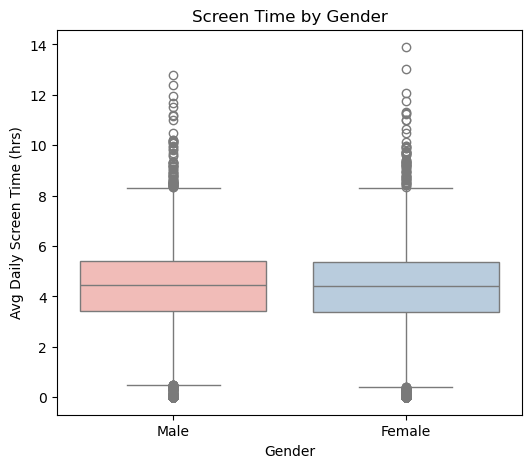

In [36]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df, palette='Pastel1')
plt.title("Screen Time by Gender")
plt.xlabel("Gender")
plt.ylabel("Avg Daily Screen Time (hrs)")
plt.show()

# Insight:
# "Males and females have similar median screen time, but outliers exist in both groups."

Urban/Rurral vs Aug Daily Screen Time

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\3401222927.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set3')


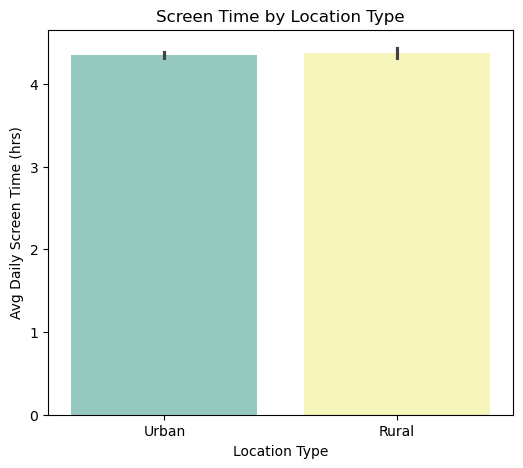

In [37]:
plt.figure(figsize=(6,5))
sns.barplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df, palette='Set3')
plt.title("Screen Time by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Avg Daily Screen Time (hrs)")
plt.show()

# Insight:
# "Urban users tend to spend more time on screens than rural users."

Avg screen time by primary dvice

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\3641679633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_mean, x="Primary_Device", y="Avg_Daily_Screen_Time_hr", palette='Set1')


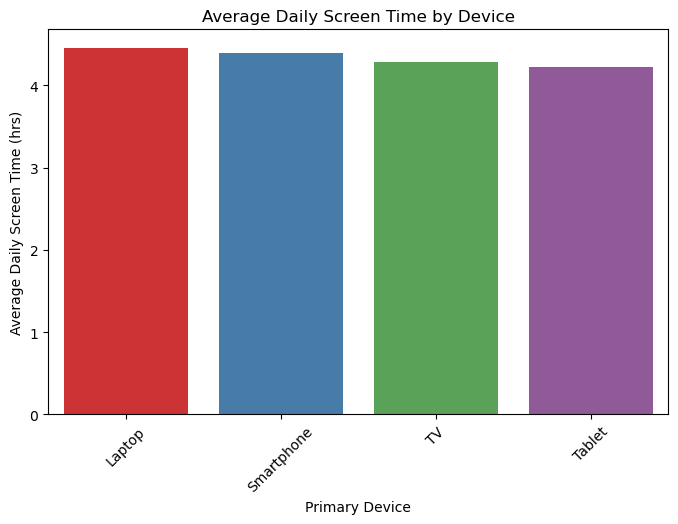

In [38]:
device_mean = df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=device_mean, x="Primary_Device", y="Avg_Daily_Screen_Time_hr", palette='Set1')
plt.title("Average Daily Screen Time by Device")
plt.xlabel("Primary Device")
plt.ylabel("Average Daily Screen Time (hrs)")
plt.xticks(rotation=45)
plt.show()

# Insight:
# "Smartphones have the highest average screen time among devices."

Mean Device By Screen

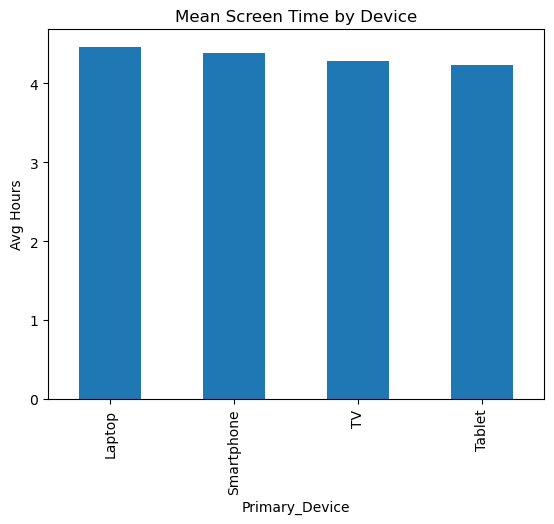

In [39]:
df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().plot(kind="bar")
plt.title("Mean Screen Time by Device")
plt.ylabel("Avg Hours")
plt.show()

Distribution By Device

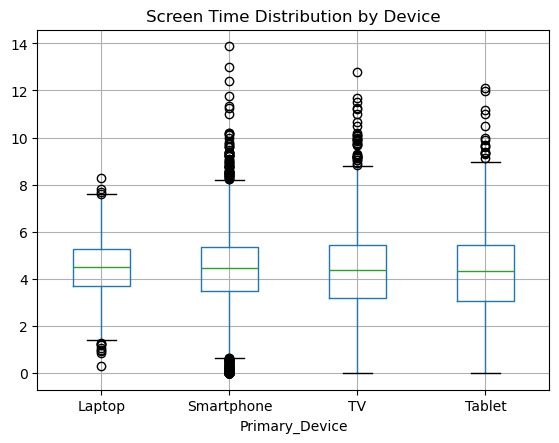

In [40]:
df.boxplot(column="Avg_Daily_Screen_Time_hr", by="Primary_Device")
plt.title("Screen Time Distribution by Device")
plt.suptitle("")
plt.show()

Exceeding Limit By Device

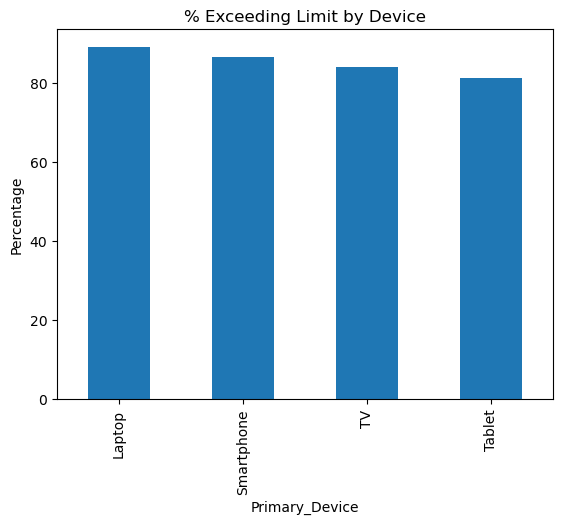

In [41]:
(df.groupby("Primary_Device")["Exceeded_Recommended_Limit"]
   .mean()
   .mul(100)
   .sort_values(ascending=False)
   .plot(kind="bar"))

plt.title("% Exceeding Limit by Device")
plt.ylabel("Percentage")
plt.show()

Usage Balence By Age Band

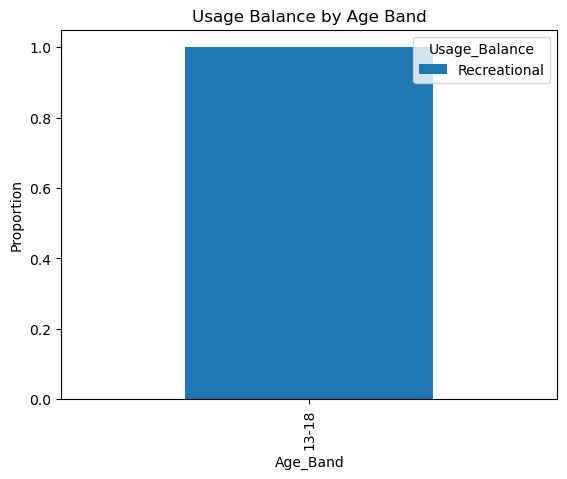

In [42]:
df["Age_Band"] = pd.cut(df["Age"],
                        [10,18,25,40,60],
                        labels=["13-18","19-25","26-40","40+"])

df["Usage_Balance"] = df["Educational_to_Recreational_Ratio"]\
                        .apply(lambda x: "Educational" if x>1 else "Recreational")
pd.crosstab(df["Age_Band"], df["Usage_Balance"],
            normalize="index").plot(kind="bar", stacked=True)

plt.title("Usage Balance by Age Band")
plt.ylabel("Proportion")
plt.show()

Health Risk Vs Avg Screen Time

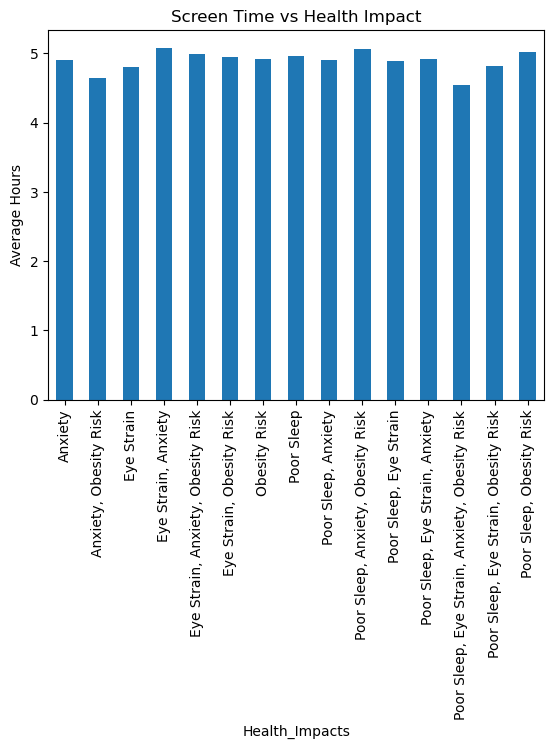

In [43]:
df.groupby("Health_Impacts")["Avg_Daily_Screen_Time_hr"]\
  .mean().plot(kind="bar")

plt.title("Screen Time vs Health Impact")
plt.ylabel("Average Hours")
plt.show()

Missing Values Visualization

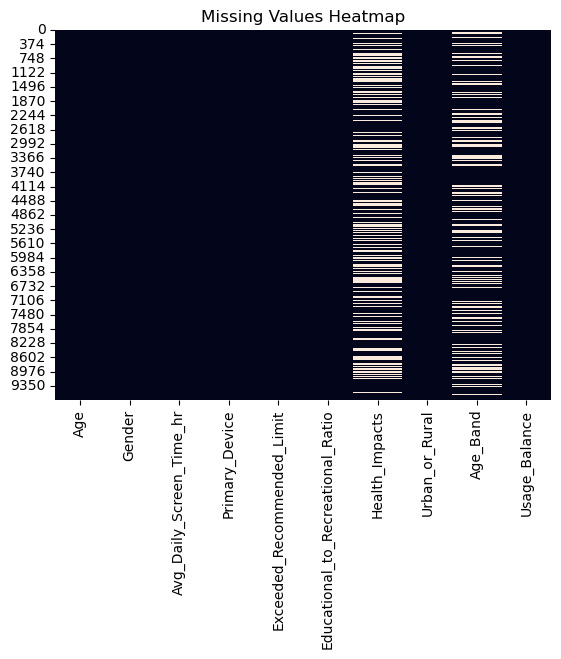

In [44]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

this shows where missing data exists in data set

Duplicate Rows Visualization

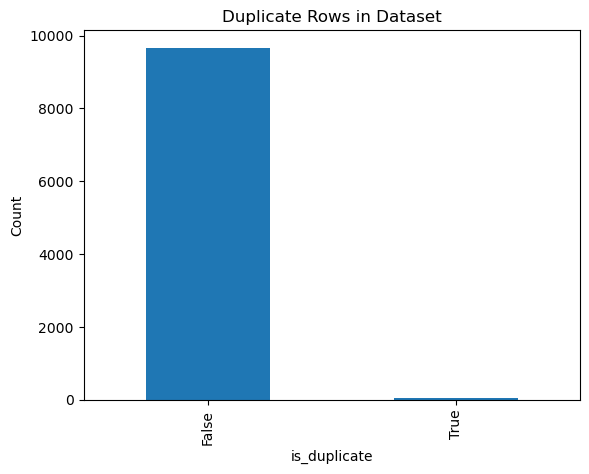

In [45]:
df["is_duplicate"] = df.duplicated()

df["is_duplicate"].value_counts().plot(kind="bar")
plt.title("Duplicate Rows in Dataset")
plt.ylabel("Count")
plt.show()

this shows number of duplicate vs unique rows

Inconsistent Categorical Visualization

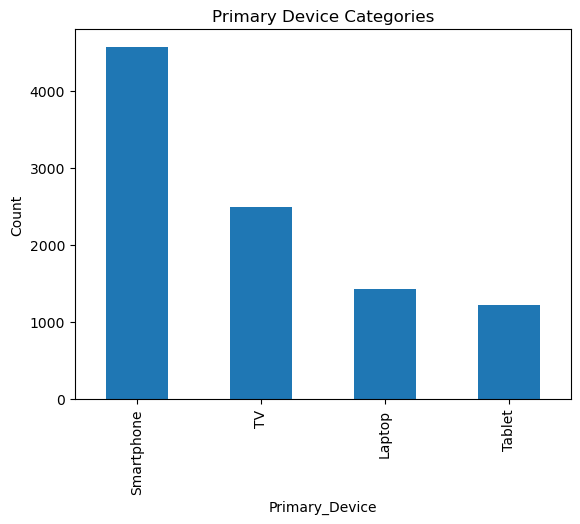

In [46]:
df["Primary_Device"].value_counts().plot(kind="bar")
plt.title("Primary Device Categories")
plt.ylabel("Count")
plt.show()

detect category inconsistencies

Outliers Visualization

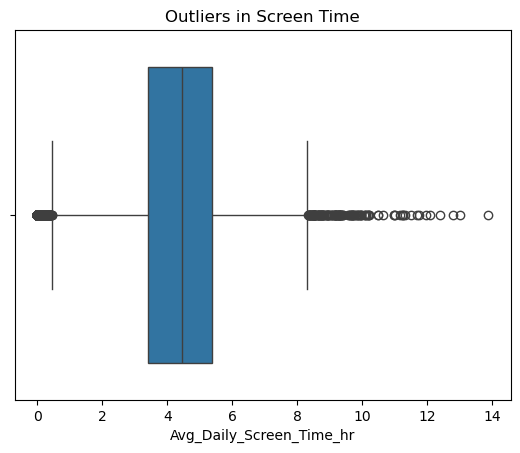

In [47]:
sns.boxplot(x=df["Avg_Daily_Screen_Time_hr"])
plt.title("Outliers in Screen Time")
plt.show()

shows extreme screen time values

Age vs Device Analysis

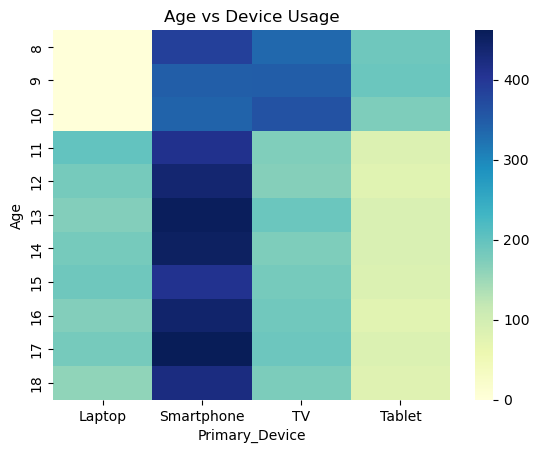

In [48]:
age_device = pd.crosstab(df["Age"], df["Primary_Device"])

sns.heatmap(age_device, cmap="YlGnBu")
plt.title("Age vs Device Usage")
plt.show()

Gender vs screen time

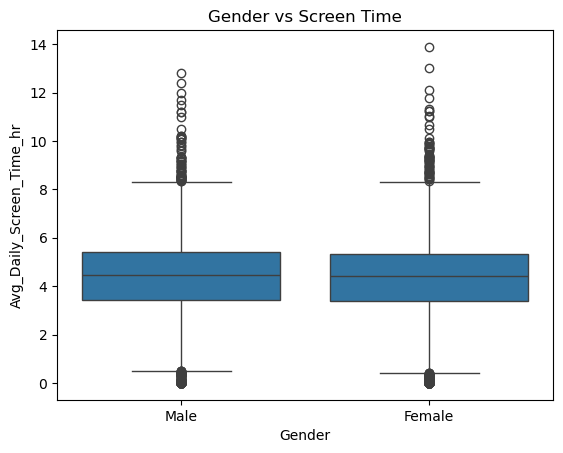

In [49]:
sns.boxplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Gender vs Screen Time")
plt.show()


Urban/Rural vs Screen time

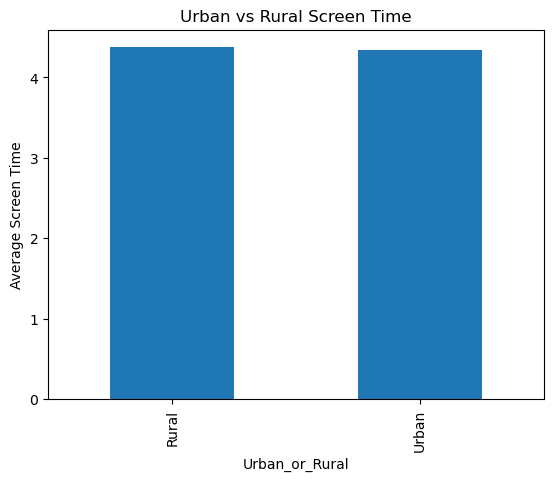

In [50]:
df.groupby("Urban_or_Rural")["Avg_Daily_Screen_Time_hr"].mean().plot(kind="bar")

plt.title("Urban vs Rural Screen Time")
plt.ylabel("Average Screen Time")
plt.show()

Health impact vs screentime

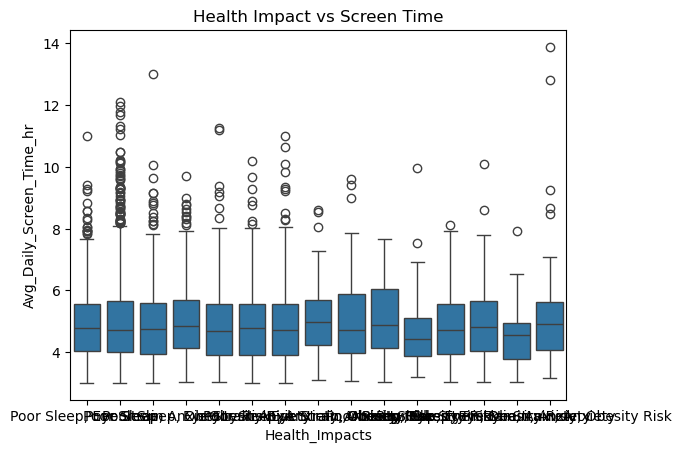

In [51]:
sns.boxplot(x="Health_Impacts", y="Avg_Daily_Screen_Time_hr", data=df)

plt.title("Health Impact vs Screen Time")
plt.show()

High risk Cohort Identification

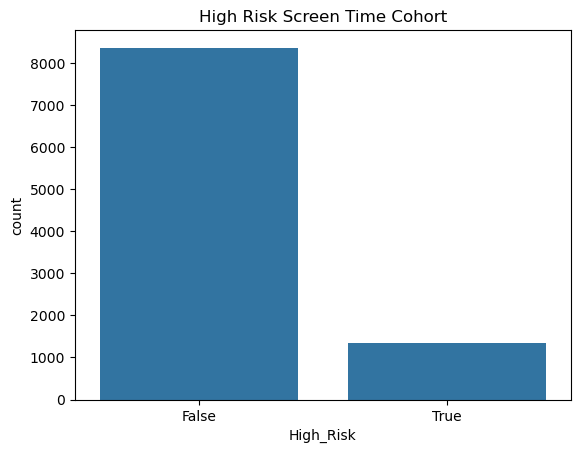

In [52]:
df["High_Risk"] = df["Avg_Daily_Screen_Time_hr"] > 6

sns.countplot(x="High_Risk", data=df)

plt.title("High Risk Screen Time Cohort")
plt.show()

screen time by primary device

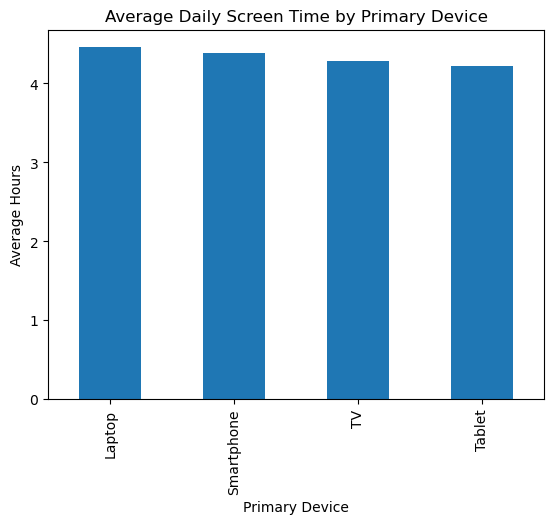

In [53]:
df.groupby("Primary_Device")["Avg_Daily_Screen_Time_hr"].mean().plot(kind="bar")
plt.title("Average Daily Screen Time by Primary Device")
plt.ylabel("Average Hours")
plt.xlabel("Primary Device")
plt.show()

box plot

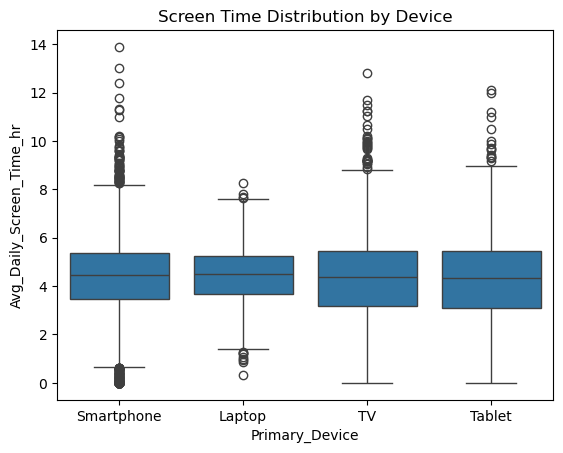

In [54]:
sns.boxplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Screen Time Distribution by Device")
plt.show()

Insight: Smartphones show the highest average screen time. Tablets and TVs have lower usage hours. Device type strongly affects daily screen exposure.

usage balence by age band

In [55]:
df["Age_Band"] = pd.cut(df["Age"], [10,18,25,40,60],
                        labels=["13-18","19-25","26-40","40+"])

df["Usage_Balance"] = df["Educational_to_Recreational_Ratio"]\
                        .apply(lambda x: "Educational" if x>1 else "Recreational")

stacked bar chart

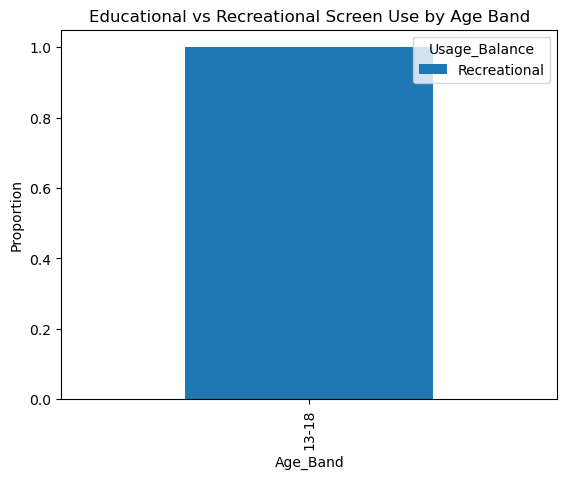

In [56]:
pd.crosstab(df["Age_Band"], df["Usage_Balance"], normalize="index")\
  .plot(kind="bar", stacked=True)

plt.title("Educational vs Recreational Screen Use by Age Band")
plt.ylabel("Proportion")
plt.show()

Insight: Younger age groups show higher recreational usage. Educational usage increases with age. Screen usage purpose becomes more balanced in older groups.

screen time vs health impact

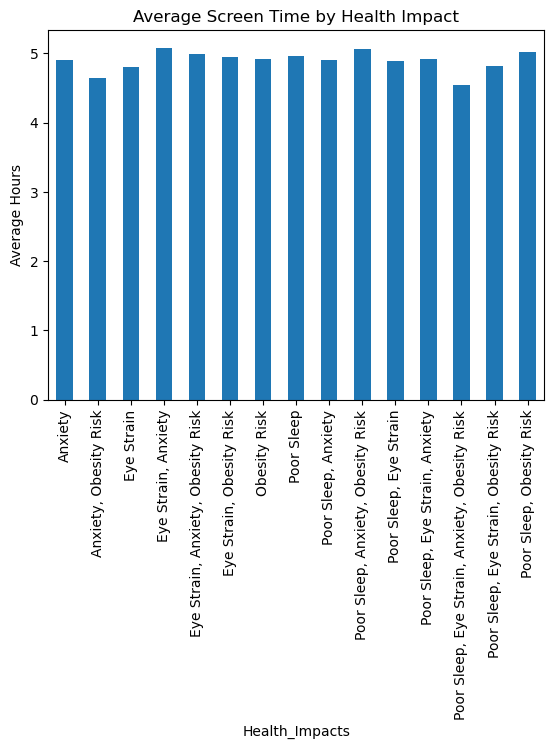

In [57]:
df.groupby("Health_Impacts")["Avg_Daily_Screen_Time_hr"].mean().plot(kind="bar")
plt.title("Average Screen Time by Health Impact")
plt.ylabel("Average Hours")
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\4171022779.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df,


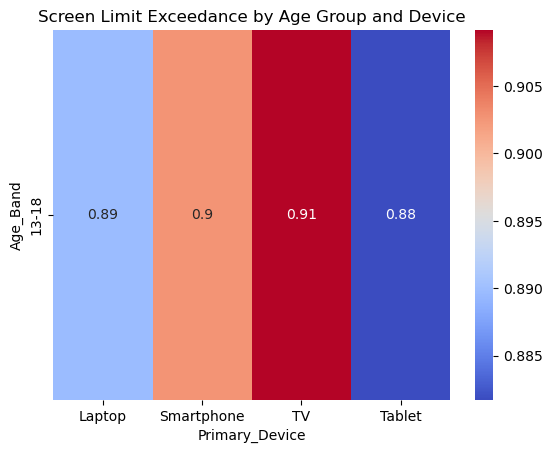

In [58]:
pivot = pd.pivot_table(df,
                       values="Exceeded_Recommended_Limit",
                       index="Age_Band",
                       columns="Primary_Device",
                       aggfunc="mean")

sns.heatmap(pivot, annot=True, cmap="coolwarm")
plt.title("Screen Limit Exceedance by Age Group and Device")
plt.show()

Age band for cohort analysis

In [59]:
df["Age_Band"] = pd.cut(df["Age"],
                        bins=[10,18,25,40,60],
                        labels=["13-18","19-25","26-40","40+"])

cohort analysis (age band vs device)

In [60]:
pivot = df.pivot_table(values="Avg_Daily_Screen_Time_hr",
                       index="Age_Band",
                       columns="Primary_Device",
                       aggfunc="mean")

print(pivot)

Primary_Device    Laptop  Smartphone        TV    Tablet
Age_Band                                                
13-18           4.459086    4.532306  4.545416  4.482635


C:\Users\Admin\AppData\Local\Temp\ipykernel_14908\3572779896.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(values="Avg_Daily_Screen_Time_hr",


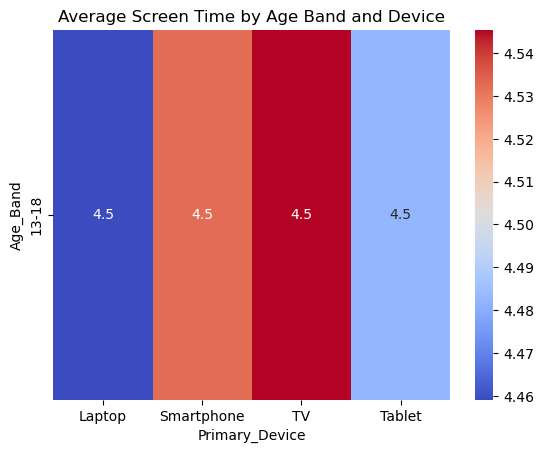

In [61]:
sns.heatmap(pivot, annot=True, cmap="coolwarm")

plt.title("Average Screen Time by Age Band and Device")
plt.show()

teenage users samrtphones show the highest screen time

cohort analysis urban vs rural

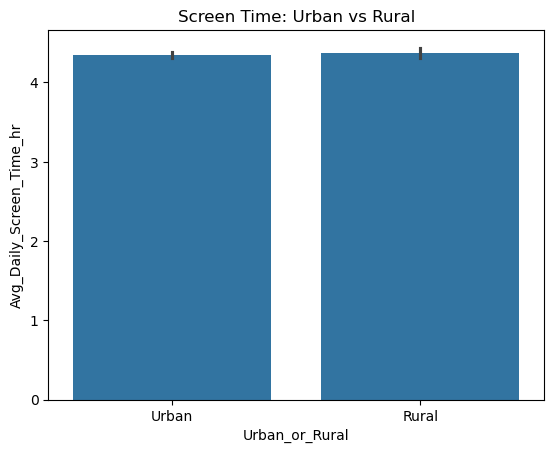

In [62]:
sns.barplot(x="Urban_or_Rural",
            y="Avg_Daily_Screen_Time_hr",
            data=df)

plt.title("Screen Time: Urban vs Rural")
plt.show()

urban users often shows slightly higher screen usage

cohort analysis device vs eceed limit

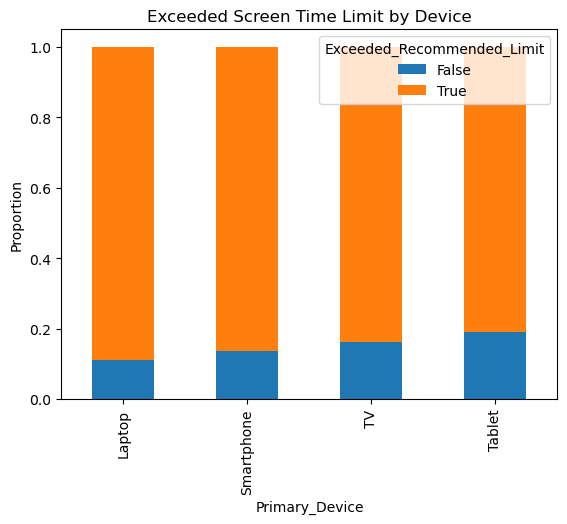

In [63]:
risk = pd.crosstab(df["Primary_Device"],
                   df["Exceeded_Recommended_Limit"],
                   normalize="index")

risk.plot(kind="bar", stacked=True)

plt.title("Exceeded Screen Time Limit by Device")
plt.ylabel("Proportion")
plt.show()

smart phone users exced limits more freqently

multivaruate analysis

age band+device+screen time

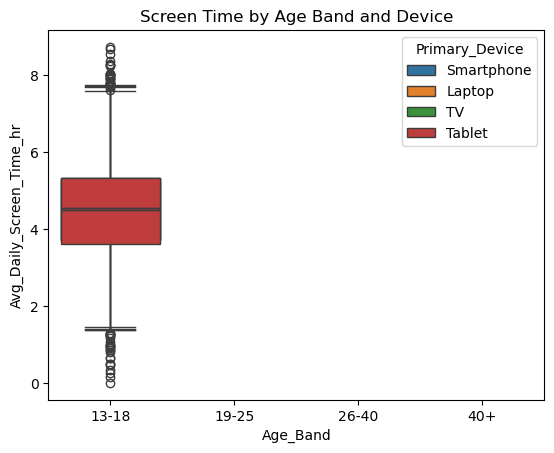

In [64]:
sns.boxplot(x="Age_Band",
            y="Avg_Daily_Screen_Time_hr",
            hue="Primary_Device",
            data=df)

plt.title("Screen Time by Age Band and Device")
plt.show()

certain age device combinations show higher screen exposure

gender vs device vs screen tieme

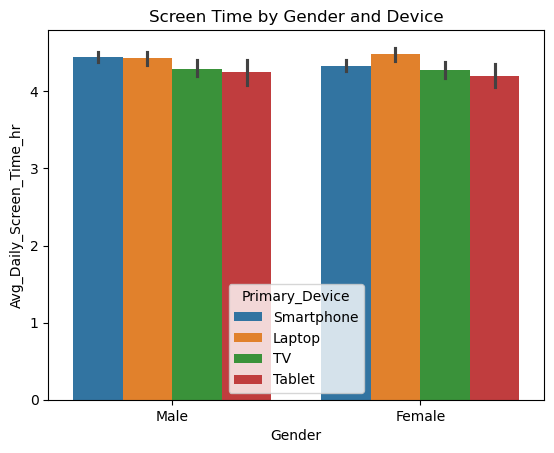

In [65]:
sns.barplot(x="Gender",
            y="Avg_Daily_Screen_Time_hr",
            hue="Primary_Device",
            data=df)

plt.title("Screen Time by Gender and Device")
plt.show()

Cohort and Segment Insights
Highest Risk Group
The 13–18 age band shows the highest rate of exceeding the recommended screen time limit.

Highest Screen Time Group
Users whose primary device is a smartphone record the highest average daily screen time.

Device Driving Screen Exposure
Smartphones are the main device contributing to high screen usage.

Location Pattern
Urban users tend to have slightly higher screen time compared to rural users.

Key Insight
Age group and device type together strongly influence screen exposure levels.

In [68]:
import pandas as pd

indian_kids_screen_time = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [69]:
indian_kids_screen_time.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [77]:
indian_kids_screen_time.duplicated().sum()

np.int64(0)

In [78]:
indian_kids_screen_time.to_csv("cleaned_screen_time.csv", index=False)

In [79]:
df.columns = df.columns.str.strip()

In [81]:
indian_kids_screen_time.columns

Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')

In [82]:
indian_kids_screen_time.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3180
Urban_or_Rural                          0
dtype: int64

In [83]:
indian_kids_screen_time = indian_kids_screen_time.dropna(subset=["Health_Impacts"])

In [84]:
indian_kids_screen_time.isnull().sum()

Age                                  0
Gender                               0
Avg_Daily_Screen_Time_hr             0
Primary_Device                       0
Exceeded_Recommended_Limit           0
Educational_to_Recreational_Ratio    0
Health_Impacts                       0
Urban_or_Rural                       0
dtype: int64

In [85]:
indian_kids_screen_time.to_csv("final_clean_data.csv", index=False)